In [5]:
import pandas as pd

def baixar_serie_bcb(codigo_serie):
    """
    Baixa uma série temporal do Banco Central (SGS) e limpa os dados.

    Args:
        codigo_serie (int): Código da série no SGS (ex: 192 para INCC-M).

    Returns:
        pd.DataFrame: DataFrame com colunas 'data' (datetime) e 'valor' (float).
    """
    url = f'http://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?formato=csv'

    # Pandas lê direto da URL.
    # sep=';' e decimal=',' resolvem o problema do formato brasileiro.
    df = pd.read_csv(url, sep=';', decimal=',')

    # Converter a coluna 'data' que vem como texto para objeto de data real
    df['data'] = pd.to_datetime(df['data'], format='%d/%m/%Y')

    # Definir a data como índice facilita muito plotar gráficos depois
    df.set_index('data', inplace=True)

    return df

# 192 = INCC-M (Índice Nacional de Custo da Construção - Mercado)
# 433 = IPCA (Índice Nacional de Preços ao Consumidor Amplo)
codigos = {
    'INCC': 192,
    'IPCA': 433
}

df_incc = baixar_serie_bcb(codigos['INCC'])
df_incc.rename(columns={'valor': 'INCC'}, inplace=True)

df_ipca = baixar_serie_bcb(codigos['IPCA'])
df_ipca.rename(columns={'valor': 'IPCA'}, inplace=True)

# Juntando tudo em uma tabela só:
df_final = df_incc.join(df_ipca, how='inner')

"""
 Mostrando as últimas 5 linhas:
print(df_final.tail())
"""

'\n Mostrando as últimas 5 linhas:\nprint(df_final.tail())\n'

In [6]:
# ---  TRATAMENTO MATEMÁTICO E FILTRAGEM ---

data_inicio = '2020-01-01'

# Cópia do dataframe original recortado:
df_filtrado = df_final[df_final.index >= data_inicio].copy()

"""
 A Matemática dos Juros Compostos (Normalização Base 100)
-   (df / 100) -> Transforma 0.5% em 0.005 (porcentagem -> decimal)
-   (1 + ...)  -> Transforma 0.005 em 1.005 (o fator de multiplicação), sendo 100% o valor inicial
-   .cumprod() -> Multiplica acumulado (Juros Compostos)
-   * 100      -> Coloca na Base 100 para o gráfico começar em 100
"""
df_filtrado['INCC_Acumulado'] = (1 + df_filtrado['INCC'] / 100).cumprod() * 100
df_filtrado['IPCA_Acumulado'] = (1 + df_filtrado['IPCA'] / 100).cumprod() * 100

"""
 Mostrando a diferença entre as colunas antes e depois do tratamento matemático:
print(df_filtrado[['INCC', 'INCC_Acumulado']].head())
print(df_filtrado[['INCC', 'INCC_Acumulado']].tail())
print(df_filtrado[['IPCA', 'IPCA_Acumulado']].head())
print(df_filtrado[['IPCA', 'IPCA_Acumulado']].tail())
"""


"\n Mostrando a diferença entre as colunas antes e depois do tratamento matemático:\nprint(df_filtrado[['INCC', 'INCC_Acumulado']].head())\nprint(df_filtrado[['INCC', 'INCC_Acumulado']].tail())\nprint(df_filtrado[['IPCA', 'IPCA_Acumulado']].head())\nprint(df_filtrado[['IPCA', 'IPCA_Acumulado']].tail())\n"

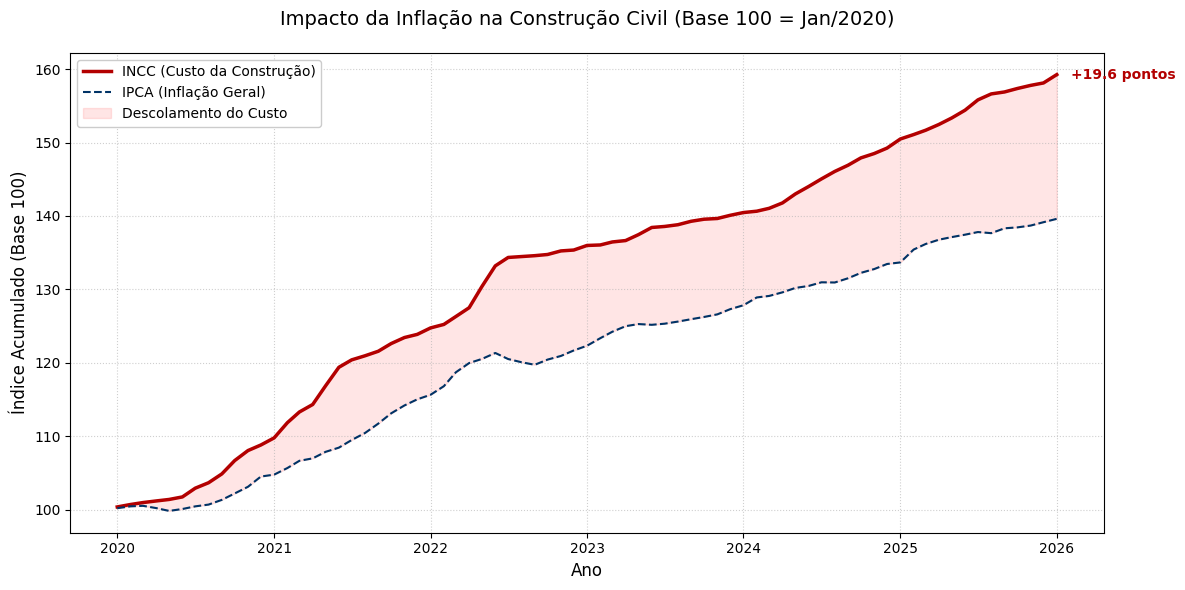

In [7]:
# --- VISUALIZAÇÃO ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_filtrado.index, df_filtrado['INCC_Acumulado'],
        label='INCC (Custo da Construção)',
        color='#b30000',
        linewidth=2.5)

ax.plot(df_filtrado.index, df_filtrado['IPCA_Acumulado'],
        label='IPCA (Inflação Geral)',
        color='#003366',
        linestyle='--',
        linewidth=1.5)

ax.fill_between(df_filtrado.index,
                df_filtrado['INCC_Acumulado'],
                df_filtrado['IPCA_Acumulado'],
                where=(df_filtrado['INCC_Acumulado'] > df_filtrado['IPCA_Acumulado']),
                color='red', alpha=0.1, interpolate=True,
                label='Descolamento do Custo')

ax.set_title('Impacto da Inflação na Construção Civil (Base 100 = Jan/2020)', fontsize=14, pad=20)
ax.set_ylabel('Índice Acumulado (Base 100)', fontsize=12)
ax.set_xlabel('Ano', fontsize=12)

ax.grid(True, linestyle=':', alpha=0.6)

ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=1)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ultimo_incc = df_filtrado['INCC_Acumulado'].iloc[-1]
ultimo_ipca = df_filtrado['IPCA_Acumulado'].iloc[-1]
diferenca = ultimo_incc - ultimo_ipca

ax.annotate(f'+{diferenca:.1f} pontos',
            xy=(df_filtrado.index[-1], ultimo_incc),
            xytext=(10, 0), textcoords='offset points',
            color='#b30000', fontweight='bold', va='center')

plt.tight_layout()

plt.savefig('analise_incc_ipca.png', dpi=300)

plt.show()